## Chapter 4- Building the LLM Architecture from Scratch

In [31]:
cfg = {
        "vocab_size":50257,
        "context_length":1024,
        "emb_dim":768,
        "n_heads":12,
        "n_layers":12,
        "drop_rate":0.1,
        "qkv_bias":False
}

In [32]:
import torch 
import torch.nn as nn

class DummyGPT(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rate"])

        #Use a place holder for the transformer blocks 
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        #Use a place holder for Layer Norm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)
    
    def forward(self,in_idx):
        batch_size,seq_len = in_idx.shape
        tok_emb = self.tok_emb(in_idx)
        pos_emb = self.pos_emb(torch.arange(seq_len,device=in_idx.device))
        x = tok_emb + pos_emb
        x = self.dropout(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits




class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
    def forward(self,x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self,cfg):
        super().__init__()
    def forward(self,x):
        return x

In [33]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [34]:
torch.manual_seed(123)
model = DummyGPT(cfg)

logits = model(batch)
print("Output Shape: ",logits.shape)
print(logits)

Output Shape:  torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2 - Layer Normalisation

In [35]:
torch.manual_seed(123)

batch_example = torch.randn(2,5)

print(batch_example)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])


In [36]:
#To combat problems like vanishing gradient and exploading gradient we use layer normalisation (we normalise the inputs)
layer = nn.Sequential(nn.Linear(5,6),nn.ReLU())
output = layer(batch_example)
print(output)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


When we do dim = 0 (along the rows) that's pretty similar to batch normalisation. We avoid do batch normalisation for llm... Because we spilt the dataset into small batches which is then sent to a gpu so normalisation would lead to unstable behaviour.

In [37]:
mean = output.mean(dim=-1,keepdim=True)
print("mean\n ",mean)

var = output.var(dim=-1,keepdim=True)
print("var\n ",var)

mean
  tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
var
  tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [38]:
#Centering around mean and making the var 1 => This is the Normalisation step

normed = (output - mean) / torch.sqrt(var)

print(normed.mean(dim=-1,keepdim =True))
print(normed.var(dim=-1,keepdim=True))

tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [39]:
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()

        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True)
        var = x.var(dim=-1,keepdim=True,unbiased=False)

        normed = (x-mean)/torch.sqrt(var+self.eps)

        return self.scale * normed + self.shift

## 4.3 Feed Forward networks with GeLU activations

In [ ]:
class GeLU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self,x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi, device=x.device, dtype=x.dtype)) *
            (x + 0.044715 * x.pow(3))
        ))

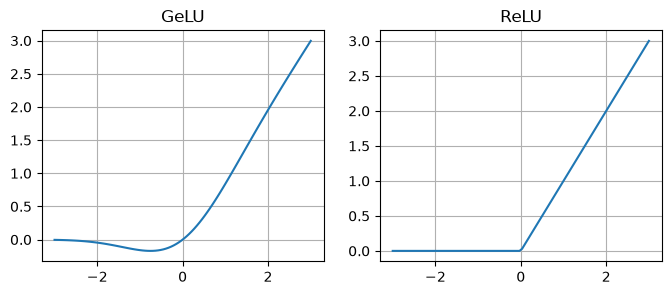

In [41]:
import matplotlib.pyplot as plt 

gelu,relu = GeLU(),nn.ReLU()

x = torch.linspace(-3,3,100)
y_gelu,y_relu = gelu(x),relu(x)


plt.figure(figsize=(8,3))
for i , (y,label) in enumerate(zip([y_gelu,y_relu],["GeLU","ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x, y)
    plt.title(label)
    plt.grid(True)


In [42]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
            GeLU(),
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
        )
    
    def forward(self,x):
        return self.layers(x)

In [43]:
ffn = FeedForward(cfg)
x = torch.randn(2,3,768)
ffn(x).shape

torch.Size([2, 3, 768])

In [44]:
ffn.layers[0].weight

Parameter containing:
tensor([[-0.0223,  0.0308,  0.0022,  ..., -0.0174, -0.0227, -0.0178],
        [-0.0027, -0.0043, -0.0274,  ...,  0.0079,  0.0112,  0.0010],
        [-0.0029,  0.0175,  0.0244,  ..., -0.0164, -0.0300,  0.0045],
        ...,
        [ 0.0255,  0.0023,  0.0277,  ..., -0.0037, -0.0134, -0.0284],
        [ 0.0266,  0.0236, -0.0193,  ...,  0.0120,  0.0061, -0.0261],
        [ 0.0222,  0.0106, -0.0190,  ..., -0.0253,  0.0320, -0.0109]],
       requires_grad=True)

## Adding Shortcut Connections

Why even use **Shortcut Connections**? Consider the example of you editing your friends essay... you can do this in two ways:
1) Throw away the entire esssay and write from scratch. 
2) Use the original essay but make modifications to it. 

Without the shortcuut connections you're basically doing the first approach which is highly inefficient. 
By using the shortcut connections you're essentially telling the model, make changes to the original input no need to create a new
representation for the input vector.

Shortcut Connections also solve the vanishing gradient problem:
Suppose you have a very deep neural neural netowrk, and it's not learning anything useful... So the gradient approaches zero which affects the early layers. Adding shortcut connections can revive the dying signal

In [45]:
class ExampleDeepNeuralNet(nn.Module):
    def __init__(self,layer_sizes,use_shortcut):
        super().__init__()

        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1],GeLU())),
            nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2],GeLU())),
            nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3],GeLU())),
            nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4],GeLU())),
            nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5],GeLU()))
        ])

    def forward(self,x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x += layer_output
            else:
                x = layer_output
        return x 

def print_gradients(model,x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output,target)
    loss.backward()

    for name,param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [46]:
layer_sizes = [3,3,3,3,3,1]
sample_input = torch.tensor([[1.,0.,-1.]])

In [47]:
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNet(layer_sizes,True)
print_gradients(model_without_shortcut,sample_input)

RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.FloatTensor [1, 3]], which is output 0 of AddBackward0, is at version 4; expected version 3 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True, check_nan=False).

In [55]:
import torch
import torch.nn as nn 

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in,d_out):
        super().__init__()
        self.d_out = d_out
        self.W_q = nn.Parameter(torch.rand(d_in,d_out),requires_grad=True)
        self.W_k = nn.Parameter(torch.rand(d_in,d_out),requires_grad=True)
        self.W_v = nn.Parameter(torch.rand(d_in,d_out),requires_grad=True)

    def forward(self,x):
        queries = x @ self.W_q  #(n,d_in) @ (d_in,d_out)
        keys = x @ self.W_k
        values = x @ self.W_v

        #Caluculating attn_weights
        attn_scores = queries @ keys.T #(n,d_out) @ (d_out,n) = (n,n)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5  ,dim=-1
            )
        
        context_vec = attn_weights @ values #(n,d_out) 
        return context_vec 

class SelfAttention_v2(nn.Module):
    def __init__(self,d_in,d_out,qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_q = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_k = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_v = nn.Linear(d_in,d_out,bias=qkv_bias)

    def forward(self,x):
        queries = self.W_q(x)
        keys = self.W_k(x)
        values = self.W_v(x)

        #Calculating Attn weights
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,
            dim = -1
        )

        #Context vector
        context_vec = attn_weights @ values
        return context_vec

class CasualAttention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_q = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_k = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_v = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length,context_length),diagonal=1)
        )

    def forward(self,x):
        b,num_tokens,d_in = x.shape

        queries = self.W_q(x) #(b,num_tokens,d_out)
        keys = self.W_k(x) #(b,num_tokens,d_out)
        values = self.W_v(x) #(b,num_tokens,d_out)

        #Calculating Attn_weights 
        attn_scores = queries @ keys.transpose(1,2) #(b,num_tokens,num_tokens)
        attn_scores = torch.masked_fill(
            input=attn_scores,
            mask = self.mask.bool()[:num_tokens,:num_tokens],
            value= -torch.inf
        ) 
        attn_weights = torch.softmax(
            input = attn_scores / keys.shape[-1]**0.5,
            dim = -1,
        ) #(b,num_tokens,num_tokens)
        attn_weights = self.dropout(attn_weights)
        context_vec = attn_weights @ values #(b,num_tokens,d_out)
        return context_vec

class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self,d_in,d_out,num_heads,context_length,dropout,qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList([CasualAttention(d_in,d_out,context_length,dropout,qkv_bias) for _ in range(num_heads)])

    def forward(self,x):
        return torch.cat([head(x) for head in self.heads],dim=-1)

class MultHeadAttention(nn.Module):
    def __init__(self,d_in,d_out,num_heads,context_length,dropout,qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out should be divisble by num_heads" 

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_q = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_k = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_v = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length,context_length),diagonal=1),
        )
        self.out_proj = nn.Linear(d_out,d_out)

    def forward(self,x):
        b,num_tokens,d_in = x.shape
        
        queries = self.W_q(x)
        keys = self.W_k(x)
        values = self.W_v(x)

        #Splitting the attention heads
        keys = keys.view(b,num_tokens,self.num_heads,self.head_dim) 
        values = values.view(b,num_tokens,self.num_heads,self.head_dim)
        queries = queries.view(b,num_tokens,self.num_heads,self.head_dim)

        keys = torch.transpose(keys,1,2) # (n,num_heads,num_tokens,head_dim)
        values = torch.transpose(values,1,2) # (n,num_heads,num_tokens,head_dim)
        queries = torch.transpose(queries,1,2) # (n,num_heads,num_tokens,head_dim)

        #Calculating Attention Weights
        attn_scores = queries @ keys.transpose(2,3) # (n,num_heads,num_tokens,head_dim) @  (n,num_heads,num_tokens,head_dim)
        attn_scores = torch.masked_fill(
            input=attn_scores,
            mask = self.mask.bool()[:num_tokens,:num_tokens],
            value=-torch.inf, 
        )

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,
            dim=-1,
        )

        attn_weights = self.dropout(attn_weights)

        #Calculating context_vec
        context_vec = (attn_weights @ values).transpose(1,2) 
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)
        return context_vec


In [49]:
import torch 
from torch.utils.data import Dataset,DataLoader
import tiktoken
import re 

class SimpleTokenizerV1:
    """Tokenizer that splits texts into words and punctuation. Will give error for new words"""
    def __init__(self,vocab:dict):
        self.str_to_int = vocab
        self.int_to_str = {s:i for i,s in vocab.items()}

    def encode(self,text):
        tokens = re.split(r'([.,?!:;"()\']|--|\s)',text)
        tokens = [item for item in tokens if item.strip()]
        ids = [self.str_to_int[s] for s in tokens]
        return ids 
    
    def decode(self,ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text) #Removes whitespace in front of the punctuation
        return text

class SimpleTokenizerV2:
    """Tokenizer that splits texts into words and punctuation. Will replace unkown words with <|unk|>"""
    def __init__(self,vocab:dict):
        self.str_to_int = vocab
        self.int_to_str = {s:i for i,s in vocab.items()}
    
    def encode(self,text):
        tokens = re.split(r'([.,?!:;"()\']|--|\s)',text)
        tokens = [item for item in tokens if item.strip()]
        tokens = [item if item in self.str_to_int else "<|unk|>" for item in tokens]

        ids = [self.str_to_int[s] for s in tokens]
        return ids 

    def decode(self,ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text) #Removes whitespace in front of the punctuation
        return text

class GPTEncoder:
    """Calls the tiktoken library for enoding and decoding. Uses gpt2 encoding."""
    def __init__(self):
        self.tokenizer = tiktoken.get_encoding("gpt2") 

    def encode(self,text,allowed_special={"<|endoftext|>"}):
        return self.tokenizer.encode(text,allowed_special=allowed_special) 
    
    def decode(self,ids):
        return self.tokenizer.decode(ids) 
    


In [56]:
import torch
from torch.utils.data import Dataset,DataLoader 

class GPTDatasetV1(Dataset):
    def __init__(self,txt,tokenizer,max_length,stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        for i in range(0,len(token_ids)-max_length,stride):
            input_chunk = token_ids[i:i+max_length]
            target_chuck = token_ids[i+1:i+max_length+1]

            self.input_ids.append(torch.tensor(input_chunk))  
            self.target_ids.append(torch.tensor(target_chuck))
    
    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self,idx):
        return self.input_ids[idx] , self.target_ids[idx] 
    
def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
    tokenizer = GPTEncoder()
    dataset = GPTDatasetV1(txt=txt,tokenizer=tokenizer,max_length=max_length,stride=stride)
    dataloader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader


In [75]:
class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.attn = MultHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self,x):
        #Shortcut for Attn Block
        
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        #Shortcut for feedforward layer
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x 

In [ ]:
cfg

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [58]:
torch.manual_seed(123)
x = torch.randn(2,4,768)
block = TransformerBlock(cfg)
out = block(x)

1


In [59]:
out.shape

torch.Size([2, 4, 768])

In [60]:
import torch 
import torch.nn as nn

class GPT(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
 
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)
    
    def forward(self,in_idx):
        batch_size,seq_len = in_idx.shape
        tok_emb = self.tok_emb(in_idx)
        pos_emb = self.pos_emb(torch.arange(seq_len,device=in_idx.device))
        x = tok_emb + pos_emb
        x = self.dropout(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


In [61]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [62]:
torch.manual_seed(123)

model = GPT(cfg)
out = model(batch)

1
1
1
1
1
1
1
1
1
1
1
1


In [63]:
batch.shape

torch.Size([2, 4])

In [64]:
out.shape

torch.Size([2, 4, 50257])

In [65]:
total_params = sum(p.numel() for p in model.parameters())
total_params

163009536

In [67]:
def generate_text(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:,-1,:]
        probas = torch.softmax(logits,dim=-1)
        id_next = torch.argmax(probas,dim=-1,keepdim=True)
        idx = torch.cat((idx,id_next),dim=1)

    return idx

In [70]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded tensor shape: ",encoded_tensor.shape)

encoded tensor shape:  torch.Size([1, 4])


In [71]:
encoded_tensor

tensor([[15496,    11,   314,   716]])

In [76]:
out = generate_text(
    model=model,
    idx = encoded_tensor,
    max_new_tokens=10,
    context_size=cfg["context_length"],

)



1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [74]:
tokenizer.decode(out.squeeze(0).tolist())

'Hello, I am Featureiman Byeswick palpMust payment shadowszman Sch'